<a href="https://colab.research.google.com/github/DeekshaKarkada/CNN-Implementation-using-Laplacian-smoothing/blob/main/CNN_Implementation_using_Laplacian_Smoothing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CT5103 Assignment 2 (Group 7)

Team members:

1) Ayushi Kashyap

2) Deeksha Karkada

3) Erin Susan Thomas

4) Harshitha

5) Kalpana Sahu

# Import Libraries and load dataset

In [ ]:
import warnings
import os
import cv2
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings('ignore')

Load all images

In [ ]:
current_dir = 'C:/Users/dkimp/Downloads/Group_7_wet_severe/Group_7_wet_severe'

In [ ]:
dir_train = current_dir + "/train"
dir_valid = current_dir + "/valid"
dir_test = current_dir + "/test"

In [ ]:
class_names = os.listdir(dir_train)
class_names

['wet_asphalt_severe', 'wet_concrete_severe', 'wet_gravel']

In [ ]:
num_classes = len(class_names)
num_classes

3

# Data Preprocessing

Preprocessing for increasing the blur quality of an image & to resize the image as per requirement of the network

In [ ]:
# Preprocessing for increasing the blur quality of an image
def is_blurry(image_path, threshold=20):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    variance_of_laplacian = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance_of_laplacian < threshold

In [ ]:
# Replacing the original image with the preprocessed image that is enhanced in the quality
def preprocess_dataset(dataset_dir, output_dir, threshold=20):
    for class_name in os.listdir(dataset_dir):
        class_dir = os.path.join(dataset_dir, class_name)
        output_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(output_class_dir, exist_ok=True)

        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)

            if not is_blurry(image_path, threshold):

                shutil.copy(image_path, os.path.join(output_class_dir, image_name))

In [ ]:
original_train_dir = 'C:/Users/dkimp/Downloads/Group_7_wet_severe/Group_7_wet_severe/train'
preprocessed_train_dir = 'C:/Users/dkimp/Downloads/Group_7_wet_severe/Group_7_wet_severe/laplacian_train'
preprocess_dataset(original_train_dir, preprocessed_train_dir)

In [ ]:
class_names = os.listdir(preprocessed_train_dir)
class_names

['wet_asphalt_severe', 'wet_concrete_severe', 'wet_gravel']

In [ ]:
# Using ImageDataGenerator for rescaling the images and choosing the class mode
def preprocessed_images(train_set, valid_set, test_set):
    train_datagen = ImageDataGenerator( rescale = 1.0/255. )
    valid_datagen  = ImageDataGenerator( rescale = 1.0/255. )
    test_datagen  = ImageDataGenerator( rescale = 1.0/255. )

    train_preprocess_data = train_datagen.flow_from_directory(
            train_set,
            target_size=(96, 96),
            batch_size=32,
            class_mode='categorical')

    valid_preprocess_data = valid_datagen.flow_from_directory(
            valid_set,
            target_size=(96, 96),
            batch_size=32,
            class_mode='categorical')

    test_preprocess_data = test_datagen.flow_from_directory(
            test_set,
            target_size=(96, 96),
            batch_size=32,
            class_mode='categorical')

    return train_preprocess_data, valid_preprocess_data, test_preprocess_data

In [ ]:
train_preprocess_data, valid_preprocess_data, test_preprocess_data = preprocessed_images(dir_train, dir_valid, dir_test)

Found 42530 images belonging to 3 classes.
Found 1320 images belonging to 3 classes.
Found 3950 images belonging to 3 classes.


The laplacian function is filtering based on threshold so this is the count of all the filtered images

In [ ]:
train_laplacian_data, valid_preprocess_data, test_preprocess_data = preprocessed_images(preprocessed_train_dir, dir_valid, dir_test)

Found 42491 images belonging to 3 classes.
Found 1320 images belonging to 3 classes.
Found 3950 images belonging to 3 classes.


In [ ]:
get_img = train_preprocess_data.next()
input_size = get_img[0].shape
input_size

(32, 96, 96, 3)

In [ ]:
input_shape = (96, 96, 3)  # Height x Width x Channels
num_classes = 3 # Labels of the images

Function to predict accuracy scores and store them for all models

In [ ]:
def predict_score(i, history):
    prediction = np.max(history.history['accuracy'])
    print('Accuracy Score for model', i, "is:", prediction)
    return prediction

In [ ]:
all_scores = []

# Model 1 - CNN Sequential Model

In [ ]:
def cnn_seq_model(input_shape, num_classes, z, activation):
    model=Sequential([
          Conv2D(filters=32, kernel_size=(15,15), strides=(4,4), activation=activation, input_shape=input_shape),
          BatchNormalization(),
          MaxPool2D(pool_size=(2,2)),
          Conv2D(filters=64, kernel_size=(5,5), strides=(1,1), activation=activation, padding="same"),
          BatchNormalization(),
          MaxPool2D(pool_size=(2,2)),
          Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), activation=activation, padding="same"),
          BatchNormalization(),
          MaxPool2D(pool_size=(2,2)),
          Flatten(),
          Dense(256,activation='relu'),
          Dropout(0.5),
          Dense(num_classes,activation='softmax')
    ])
    return model


In [ ]:
model1 = cnn_seq_model(input_shape, num_classes, z=10, activation='softmax')
model1.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)
model1.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 21, 21, 32)        21632     
                                                                 
 batch_normalization (Batch  (None, 21, 21, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 10, 10, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 64)        51264     
                                                                 
 batch_normalization_1 (Bat  (None, 10, 10, 64)        256       
 chNormalization)                                                
                                                      

In [ ]:
history1 = model1.fit(train_preprocess_data, batch_size=32, epochs=8, validation_data=valid_preprocess_data)

Epoch 1/8
1330/1330 [==============================] - 489s 367ms/step - loss: 0.4552 - accuracy: 0.8641 - val_loss: 1.0461 - val_accuracy: 0.6364
Epoch 2/8
1330/1330 [==============================] - 338s 254ms/step - loss: 0.4533 - accuracy: 0.8650 - val_loss: 1.0377 - val_accuracy: 0.6409
Epoch 3/8
1330/1330 [==============================] - 217s 163ms/step - loss: 0.4494 - accuracy: 0.8659 - val_loss: 0.9881 - val_accuracy: 0.6576
Epoch 4/8
1330/1330 [==============================] - 295s 222ms/step - loss: 0.4475 - accuracy: 0.8662 - val_loss: 0.9834 - val_accuracy: 0.6561
Epoch 5/8
1330/1330 [==============================] - 164s 123ms/step - loss: 0.4446 - accuracy: 0.8666 - val_loss: 0.9717 - val_accuracy: 0.6591
Epoch 6/8
1330/1330 [==============================] - 121s 91ms/step - loss: 0.4438 - accuracy: 0.8681 - val_loss: 1.0006 - val_accuracy: 0.6485
Epoch 7/8
1330/1330 [==============================] - 100s 75ms/step - loss: 0.4400 - accuracy: 0.8677 - val_loss: 1.0

In [ ]:
prediction1 = predict_score(1, history1)
all_scores.append(prediction1)

Accuracy Score for model 1 is: 0.8681166172027588


# Model 2 - AlexNet

References:
* H. Eldem, E. ¨ Ulker, and O. Y. Is ¸ıklı, “Alexnet architecture variations with transfer learning for classification of wound images,” Engineering Science and Technology, an International Journal, vol. 45, p. 101490, Sep 2023.
* https://learnopencv.com/understanding-alexnet/
* https://medium.com/@syedsajjad62/alex-net-explanation-and-implementation-in-tensorflow-and-keras-8047efeb7a0f

In [ ]:
from tensorflow.keras import models, layers

def modified_alexnet(input_shape, num_classes, z):
    model = models.Sequential()

    # 1st Conv Layer
    model.add(layers.Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

    # Rest Conv Layers
    model.add(layers.Conv2D(filters=256, kernel_size=(5, 5), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

    model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
    #model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

    # Flattening
    model.add(layers.Flatten())

    # 1st Dense Layer
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    # 2nd Dense Layer
    model.add(layers.Dense(z, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


In [ ]:
model2 = modified_alexnet(input_shape, num_classes, z=22)

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model2.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_35 (Conv2D)          (None, 22, 22, 96)        34944     
                                                                 
 batch_normalization_20 (Ba  (None, 22, 22, 96)        384       
 tchNormalization)                                               
                                                                 
 max_pooling2d_25 (MaxPooli  (None, 10, 10, 96)        0         
 ng2D)                                                           
                                                                 
 conv2d_36 (Conv2D)          (None, 10, 10, 256)       614656    
                                                                 
 batch_normalization_21 (Ba  (None, 10, 10, 256)       1024      
 tchNormalization)                                               
                                                      

In [ ]:
history2 = model2.fit(train_laplacian_data, batch_size=32, epochs=10, validation_data=valid_preprocess_data)

Epoch 1/10
1328/1328 [==============================] - 674s 502ms/step - loss: 0.5288 - accuracy: 0.8572 - val_loss: 0.9269 - val_accuracy: 0.6212
Epoch 2/10
1328/1328 [==============================] - 280s 211ms/step - loss: 0.4140 - accuracy: 0.8593 - val_loss: 3.7204 - val_accuracy: 0.6212
Epoch 3/10
1328/1328 [==============================] - 255s 192ms/step - loss: 0.4013 - accuracy: 0.8593 - val_loss: 0.8397 - val_accuracy: 0.6212
Epoch 4/10
1328/1328 [==============================] - 246s 185ms/step - loss: 0.3902 - accuracy: 0.8594 - val_loss: 1.7545 - val_accuracy: 0.6212
Epoch 5/10
1328/1328 [==============================] - 239s 180ms/step - loss: 0.3905 - accuracy: 0.8594 - val_loss: 0.8052 - val_accuracy: 0.6212
Epoch 6/10
1328/1328 [==============================] - 253s 190ms/step - loss: 0.3722 - accuracy: 0.8594 - val_loss: 0.8832 - val_accuracy: 0.6212
Epoch 7/10
1328/1328 [==============================] - 238s 179ms/step - loss: 0.3560 - accuracy: 0.8594 - val_

In [ ]:
prediction2 = predict_score(2, history2)
all_scores.append(prediction2)

Accuracy Score for model 2 is: 0.8593584299087524


# Model 3 - Custom activation function Seq model

Using a custom activation function `gai_relu_activation` as a paramenter for the sequential model to see the performance

Gai-ReLU activation function:

$$
f(x) = \begin{cases}
\ln(x+1) + ax & \text{if } x \geq 0 \\
\frac{ax}{1 + |ax|} & \text{if } x < 0
\end{cases}
$$



Reference: L. Cheng, X. Zhang, and J. Shen, “Road surface condition classification using Deep Learning,” Journal of Visual Communication and Image Representation, vol. 64, p. 102638, Oct. 2019. doi:10.1016/j.jvcir.2019.102638

In [ ]:
def gai_relu_activation(x, a=0.01):
    """
    Parameters:
          x: Input of the activation function
          a: Leakage hyper-parameter that can be learned by the backpropagation algorithm
             (defaults to 0.01; this value based on the paper this function is used from)
    Returns: Output tensor after applying the Gai-ReLU activation function
    """
    return tf.where(x >= 0, tf.math.log(x + 1) + a * x, a * x / (1 + tf.abs(a * x)))

In [ ]:
model3 = cnn_seq_model(input_shape, num_classes, z=10, activation=gai_relu_activation)
model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model3.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_27 (Conv2D)          (None, 21, 21, 32)        21632     
                                                                 
 batch_normalization_15 (Ba  (None, 21, 21, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 10, 10, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_28 (Conv2D)          (None, 10, 10, 64)        51264     
                                                                 
 batch_normalization_16 (Ba  (None, 10, 10, 64)        256       
 tchNormalization)                                               
                                                      

In [ ]:
history3 = model3.fit(train_preprocess_data, batch_size=64, epochs=12, validation_data=valid_preprocess_data)

Epoch 1/12
1330/1330 [==============================] - 402s 301ms/step - loss: nan - accuracy: 0.0690 - val_loss: nan - val_accuracy: 0.1894
Epoch 2/12
1330/1330 [==============================] - 262s 197ms/step - loss: nan - accuracy: 0.0508 - val_loss: nan - val_accuracy: 0.1894
Epoch 3/12
1330/1330 [==============================] - 200s 151ms/step - loss: nan - accuracy: 0.0508 - val_loss: nan - val_accuracy: 0.1894
Epoch 4/12
1330/1330 [==============================] - 165s 124ms/step - loss: nan - accuracy: 0.0508 - val_loss: nan - val_accuracy: 0.1894
Epoch 5/12
1330/1330 [==============================] - 144s 108ms/step - loss: nan - accuracy: 0.0508 - val_loss: nan - val_accuracy: 0.1894
Epoch 6/12
1330/1330 [==============================] - 147s 111ms/step - loss: nan - accuracy: 0.0508 - val_loss: nan - val_accuracy: 0.1894
Epoch 7/12
1330/1330 [==============================] - 180s 135ms/step - loss: nan - accuracy: 0.0508 - val_loss: nan - val_accuracy: 0.1894
Epoch 

In [ ]:
prediction3 = predict_score(3, history3)
all_scores.append(prediction3)

Accuracy Score for model 3 is: 0.06898659467697144


# Model 4 - Step Decay

Using a function for step decay as the learning rate scheduler for the alexnet model

Using step decay function: We define a step decay function step_decay(epoch) to regulate the learning rate. This function reduces the learning rate by a factor (drop) after a certain number of epochs (epochs_drop).

References: https://machinelearningmastery.com/using-learning-rate-schedules-deep-learning-models-python-keras/

In [ ]:
def step_decay(epoch):
    initial_lr = 0.01  # Initial learning rate
    drop = 0.5         # Factor by which the learning rate will be reduced
    epochs_drop = 10   # Number of epochs after which to reduce the learning rate
    lr = initial_lr * drop ** (epoch // epochs_drop)
    return lr

We compile our model using the Stochastic Gradient Descent (SGD) optimizer with an initial learning rate (initial_learning_rate) of 0.01. This optimizer will be utilized along with the step decay scheduler during training.

We employ a learning rate scheduler callback, LearningRateScheduler, to dynamically adjust the learning rate according to the step decay function during training.

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

model4 = modified_alexnet(input_shape, num_classes, z=18)

#opt = tf.keras.optimizer.SGD(learning_rate=0.01)
model4.compile(loss='categorical_crossentropy', optimizer=tf.optimizers.AdamW(learning_rate=0.01), metrics=['accuracy'])

# learning rate scheduler callback
lr_scheduler = LearningRateScheduler(step_decay)
model4.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_30 (Conv2D)          (None, 22, 22, 96)        34944     
                                                                 
 batch_normalization_18 (Ba  (None, 22, 22, 96)        384       
 tchNormalization)                                               
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 10, 10, 96)        0         
 ng2D)                                                           
                                                                 
 conv2d_31 (Conv2D)          (None, 10, 10, 256)       614656    
                                                                 
 batch_normalization_19 (Ba  (None, 10, 10, 256)       1024      
 tchNormalization)                                               
                                                      

In [ ]:
history4 = model4.fit(train_laplacian_data, batch_size=64, epochs=14, validation_data=test_preprocess_data, callbacks=[lr_scheduler])

Epoch 1/14
1328/1328 [==============================] - 317s 236ms/step - loss: 1.9945 - accuracy: 0.8585 - val_loss: 1.1733 - val_accuracy: 0.5949 - lr: 0.0100
Epoch 2/14
1328/1328 [==============================] - 315s 237ms/step - loss: 0.4982 - accuracy: 0.8594 - val_loss: 1.2031 - val_accuracy: 0.5949 - lr: 0.0100
Epoch 3/14
1328/1328 [==============================] - 299s 225ms/step - loss: 0.4982 - accuracy: 0.8594 - val_loss: 1.2045 - val_accuracy: 0.5949 - lr: 0.0100
Epoch 4/14
1328/1328 [==============================] - 296s 223ms/step - loss: 0.4982 - accuracy: 0.8594 - val_loss: 1.2156 - val_accuracy: 0.5949 - lr: 0.0100
Epoch 5/14
1328/1328 [==============================] - 325s 245ms/step - loss: 0.4983 - accuracy: 0.8594 - val_loss: 1.1405 - val_accuracy: 0.5949 - lr: 0.0100
Epoch 6/14
1328/1328 [==============================] - 337s 254ms/step - loss: 0.4983 - accuracy: 0.8594 - val_loss: 1.1906 - val_accuracy: 0.5949 - lr: 0.0100
Epoch 7/14
1328/1328 [============

In [ ]:
prediction4 = predict_score(4, history4)
all_scores.append(prediction4)

Accuracy Score for model 4 is: 0.8593584299087524


In [ ]:
best_val = max(all_scores)
print("Best prediction value :",best_val)

Best prediction value : 0.8681166172027588


# Loss Curves & Accuracy Curves

References:
https://machinelearningmastery.com/using-learning-rate-schedules-deep-learning-models-python-keras/

In [ ]:
def plot_graph(i, model, history):
    print('Graph for model',i)
    f,ax=plt.subplots(2,1,figsize=(6,6))

    ax[0].plot(model.history.history['loss'],color='b',label='Training Loss')
    ax[0].plot(model.history.history['val_loss'],color='r',label='Validation Loss')

    # Plotting the training accuracy and validation accuracy
    ax[1].plot(model.history.history['accuracy'],color='b',label='Training  Accuracy')
    ax[1].plot(model.history.history['val_accuracy'],color='r',label='Validation Accuracy')

    plt.legend()

Loss curve (1st graph) and Accuracy curve (2nd graph) for Model 1: CNN Sequential Model

Graph for model 1


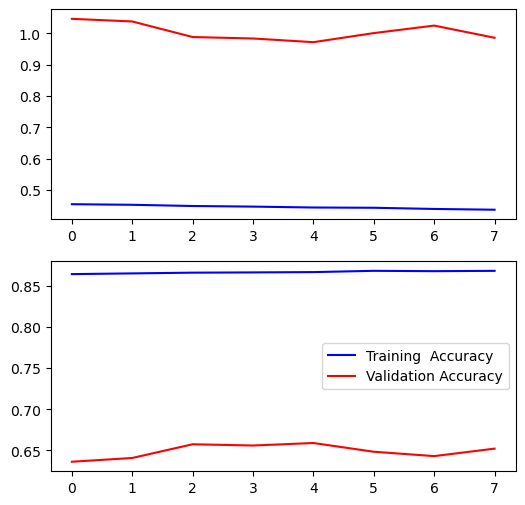

In [ ]:
plot_graph(1, model1, history1)

Loss curve (1st graph) and Accuracy curve (2nd graph) for Model 2: AlexMet

Graph for model 2


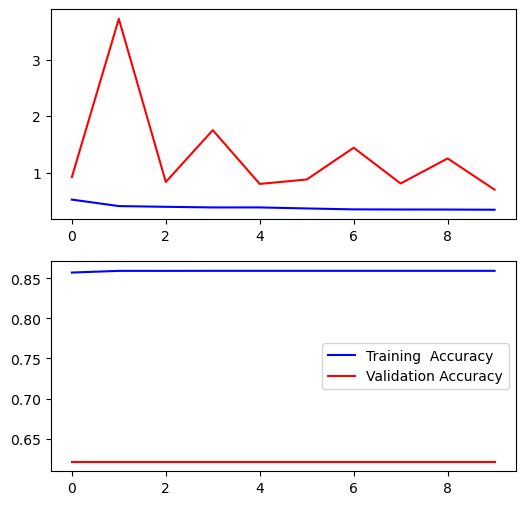

In [ ]:
plot_graph(2, model2, history2)

Loss curve (1st graph) and Accuracy curve (2nd graph) for Model 3: Custom activation function Seq model

Graph for model 3


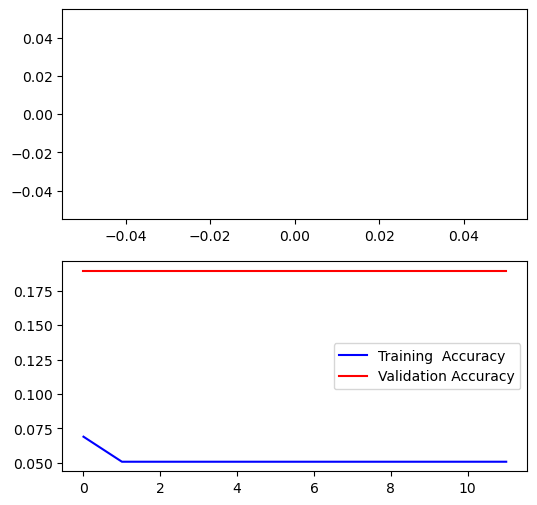

In [ ]:
plot_graph(3, model3, history3)

Loss curve (1st graph) and Accuracy curve (2nd graph) for Model 4: Step Decay

Graph for model 4


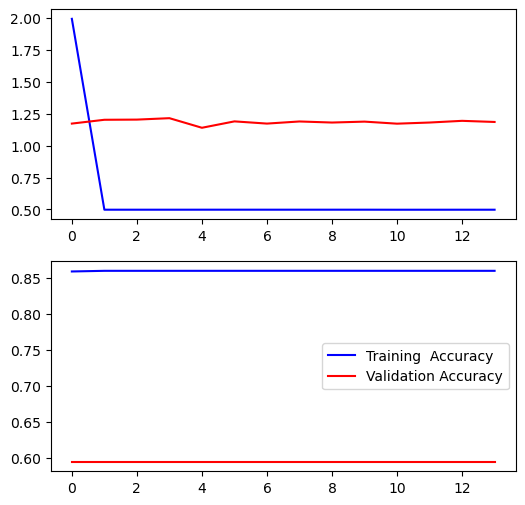

In [ ]:
plot_graph(4, model4, history4)